<a href="https://colab.research.google.com/github/ZullNgoding/Ekstraksi_Citra/blob/main/2218090_MuhammadZulfan_EkstraksiFiturWarnaTanamanCabai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--- Memproses 10 Citra Tanaman Cabai --- 

Citra: Cabai1.JPG


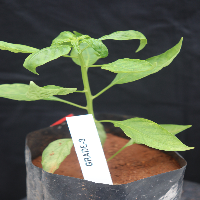

------------------------------
Citra: Cabai6.JPG


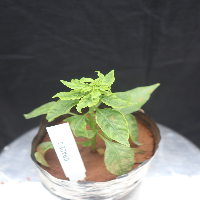

------------------------------
Citra: Cabai5.JPG


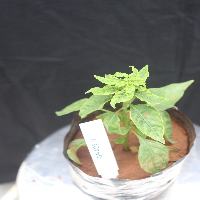

------------------------------
Citra: Cabai4.JPG


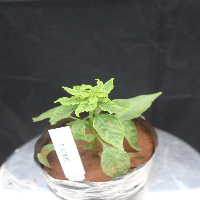

------------------------------
Citra: Cabai3.JPG


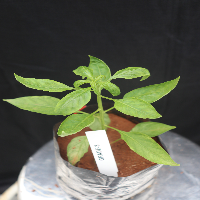

------------------------------
Citra: Cabai2.JPG


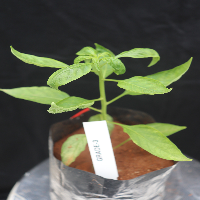

------------------------------
Citra: Cabai10.JPG


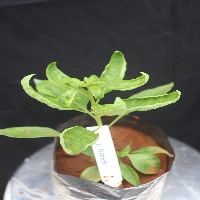

------------------------------
Citra: Cabai9.JPG


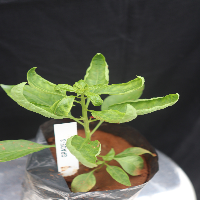

------------------------------
Citra: Cabai8.JPG


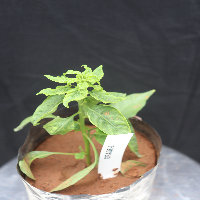

------------------------------
Citra: Cabai7.JPG


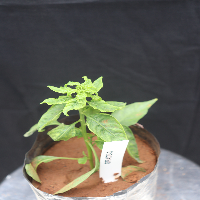

------------------------------

TABEL HASIL EKSTRAKSI FITUR WARNA


,Nama_File,Mean_Hue,Mean_Saturation,Mean_Value,StdDev_Hue,StdDev_Saturation,StdDev_Value
0,Cabai1.JPG,81.84,56.79,101.82,41.91,41.09,69.96
1,Cabai6.JPG,80.63,38.24,123.98,45.69,36.87,81.22
2,Cabai5.JPG,81.14,36.65,132.14,45.12,35.01,77.45
3,Cabai4.JPG,86.32,35.76,117.42,43.42,36.19,77.48
4,Cabai3.JPG,67.59,41.51,102.88,48.28,51.95,75.61
5,Cabai2.JPG,75.29,45.78,98.27,44.56,48.73,71.87
6,Cabai10.JPG,80.65,48.29,109.55,42.86,46.81,72.22
7,Cabai9.JPG,77.53,48.77,98.25,47.11,51.20,70.87
8,Cabai8.JPG,83.21,50.31,116.76,43.23,42.00,69.05
9,Cabai7.JPG,88.28,46.44,110.11,42.53,40.20,66.65


In [10]:
import cv2
import numpy as np
import os
import pandas as pd
from google.colab import drive
from google.colab.patches import cv2_imshow

def ekstraksi_warna_hsv_dengan_tampilan(folder_path):
    data_fitur = []

    # Ambil daftar file gambar
    valid_formats = ('.jpg', '.jpeg', '.png', '.JPG', '.PNG')
    if not os.path.exists(folder_path):
        print(f"Error: Folder '{folder_path}' tidak ditemukan.")
        return None

    file_list = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_formats)]

    if not file_list:
        print("Folder kosong atau tidak ada file gambar yang sesuai.")
        return None

    print(f"--- Memproses {len(file_list)} Citra Tanaman Cabai --- \n")

    for filename in file_list:
        path = os.path.join(folder_path, filename)
        img = cv2.imread(path)

        if img is not None:
            # Resize sedikit agar tampilan di Colab rapi
            img_disp = cv2.resize(img, (200, 200))
            print(f"Citra: {filename}")
            cv2_imshow(img_disp)

            # --- PROSES EKSTRAKSI WARNA (HSV) ---
            # Resize standar untuk perhitungan
            img_proc = cv2.resize(img, (256, 256))
            hsv_img = cv2.cvtColor(img_proc, cv2.COLOR_BGR2HSV)

            # Hitung Rata-rata (Mean)
            mean_hsv = cv2.mean(hsv_img)[:3]

            # Hitung Standar Deviasi
            std_hsv = np.std(hsv_img, axis=(0, 1))

            # Simpan Data ke List
            data_fitur.append({
                "Nama_File": filename,
                "Mean_Hue": round(mean_hsv[0], 2),
                "Mean_Saturation": round(mean_hsv[1], 2),
                "Mean_Value": round(mean_hsv[2], 2),
                "StdDev_Hue": round(std_hsv[0], 2),
                "StdDev_Saturation": round(std_hsv[1], 2),
                "StdDev_Value": round(std_hsv[2], 2)
            })
            print("-" * 30)
        else:
            print(f"Gagal memuat: {filename}")

    # Konversi ke DataFrame
    df = pd.DataFrame(data_fitur)
    return df

# --- KONFIGURASI PATH ---
PATH_DATASET = '/content/drive/MyDrive/Colab Notebooks/Dataset_Tanaman_cabai/'

# Jalankan Ekstraksi
df_hasil = ekstraksi_warna_hsv_dengan_tampilan(PATH_DATASET)

if df_hasil is not None:
    # Tampilkan Tabel Akhir
    print("\n" + "="*50)
    print("TABEL HASIL EKSTRAKSI FITUR WARNA")
    print("="*50)
    display(df_hasil)

In [12]:
path_csv = '/content/drive/MyDrive/Colab Notebooks/hasil_ekstraksi_hsv.csv'
path_xlsx = '/content/drive/MyDrive/Colab Notebooks/hasil_ekstraksi_hsv.xlsx'

df_hasil.to_csv(path_csv, index=False)
df_hasil.to_excel(path_xlsx, index=False)

print(f"File sukses tersimpan permanen di Drive: {path_csv}")

File sukses tersimpan permanen di Drive: /content/drive/MyDrive/Colab Notebooks/hasil_ekstraksi_hsv.csv
